In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")


Load Raw Data

In [3]:
df = pd.read_csv("../data/raw/incident_ml_raw.csv")
df.head()


,number,incident_state,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,contact_type,location,category,subcategory,u_symptom,impact,urgency,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,caused_by,closed_code,resolved_by,opened_at,sys_updated_at,closed_at,final_resolved_at,resolution_time_hours,aging_days,priority,sla_breach_flag,created_month,is_active
0,INC0000045,New,0,0,0,True,Caller 2403,Opened by 8,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,2 - Medium,2 - Medium,Group 56,?,True,False,Do Not Notify,?,?,?,code 5,Resolved by 149,29-02-2016 01:16,29-02-2016 01:23,05-03-2016 12:00,29-02-2016 11:29,10.216667,0,3,0,2016-02,1
1,INC0000047,New,0,0,0,True,Caller 2403,Opened by 397,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,2 - Medium,2 - Medium,Group 70,Resolver 89,True,False,Do Not Notify,?,?,?,code 5,Resolved by 81,29-02-2016 04:40,29-02-2016 04:57,06-03-2016 10:00,01-03-2016 09:52,29.200000,1,3,1,2016-02,1
2,INC0000057,New,0,0,0,True,Caller 4416,Opened by 8,Phone,Location 204,Category 20,Subcategory 125,Symptom 471,2 - Medium,2 - Medium,Group 70,?,True,False,Do Not Notify,?,?,?,code 10,Resolved by 5,29-02-2016 06:10,29-02-2016 06:26,06-03-2016 03:00,01-03-2016 02:55,20.750000,0,3,0,2016-02,1
3,INC0000060,New,0,0,0,True,Caller 4491,Opened by 180,Phone,Location 204,Category 9,Subcategory 97,Symptom 450,2 - Medium,2 - Medium,Group 25,Resolver 125,True,False,Do Not Notify,?,?,?,code 3,Resolved by 113,29-02-2016 06:38,29-02-2016 06:42,07-03-2016 13:00,02-03-2016 12:06,53.466667,2,3,1,2016-02,1
4,INC0000062,New,0,0,0,True,Caller 3765,Opened by 180,Phone,Location 93,Category 53,Subcategory 168,Symptom 232,2 - Medium,2 - Medium,Group 70,?,True,False,Do Not Notify,?,?,?,code 7,Resolved by 62,29-02-2016 06:58,29-02-2016 07:26,05-03-2016 16:00,29-02-2016 15:51,8.883333,0,3,0,2016-02,1


Dataset Size

In [4]:
df.shape


(24918, 35)

Number of rows = 24918

Number of columns = 35

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24918 entries, 0 to 24917
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   number                   24918 non-null  object 
 1   incident_state           24918 non-null  object 
 2   reassignment_count       24918 non-null  int64  
 3   reopen_count             24918 non-null  int64  
 4   sys_mod_count            24918 non-null  int64  
 5   made_sla                 24918 non-null  bool   
 6   caller_id                24918 non-null  object 
 7   opened_by                24918 non-null  object 
 8   contact_type             24918 non-null  object 
 9   location                 24918 non-null  object 
 10  category                 24918 non-null  object 
 11  subcategory              24918 non-null  object 
 12  u_symptom                24918 non-null  object 
 13  impact                   24918 non-null  object 
 14  urgency               

Target Distribution

In [6]:
df['sla_breach_flag'].value_counts()
df['sla_breach_flag'].value_counts(normalize=True)


sla_breach_flag
1    0.517738
0    0.482262
Name: proportion, dtype: float64

~52% of incidents breach SLA.
The dataset is relatively balanced, so class imbalance handling may be minimal.
Recall will still be prioritized to catch risky incidents early.


Aging Buckets

In [7]:
#df['aging_bucket'].value_counts()
df.columns

Index(['number', 'incident_state', 'reassignment_count', 'reopen_count',
       'sys_mod_count', 'made_sla', 'caller_id', 'opened_by', 'contact_type',
       'location', 'category', 'subcategory', 'u_symptom', 'impact', 'urgency',
       'assignment_group', 'assigned_to', 'knowledge',
       'u_priority_confirmation', 'notify', 'problem_id', 'rfc', 'caused_by',
       'closed_code', 'resolved_by', 'opened_at', 'sys_updated_at',
       'closed_at', 'final_resolved_at', 'resolution_time_hours', 'aging_days',
       'priority', 'sla_breach_flag', 'created_month', 'is_active'],
      dtype='object')

Resolution Time (Regression Target)

<Axes: >

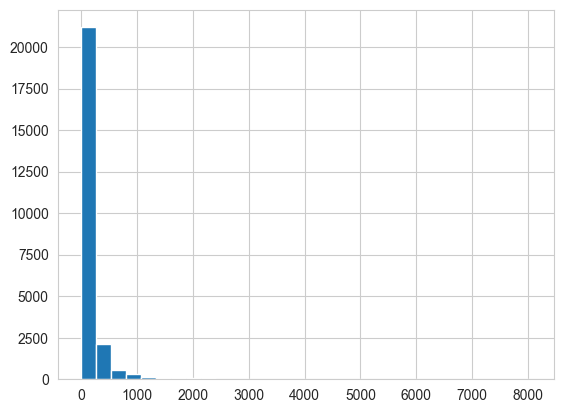

In [9]:
df['resolution_time_hours'].describe()
df['resolution_time_hours'].hist(bins=30)


Resolution Time Observation
Resolution time appears right-skewed.
A small number of incidents take much longer to resolve, which may impact SLA risk.
Log transformation may be considered later.

<Axes: >

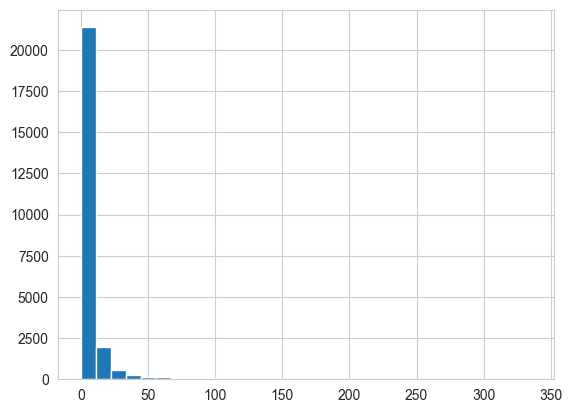

In [10]:
df['aging_days'].describe()
df['aging_days'].hist(bins=30)

Incident Aging Observation
Most incidents close within a limited number of days, but long-aging outliers exist.
Aging buckets will be derived during feature engineering


Priority / Impact / Urgency

In [15]:
df['priority'].value_counts()

priority
3    23681
4      741
2      311
1      185
Name: count, dtype: int64

In [13]:
df['impact'].value_counts()

impact
2 - Medium    23906
3 - Low         726
1 - High        286
Name: count, dtype: int64

In [14]:
df['urgency'].value_counts()

urgency
2 - Medium    23848
3 - Low         675
1 - High        395
Name: count, dtype: int64

ITSM Severity Signals
Priority, impact, and urgency distributions appear reasonable.
These variables are expected to be strong predictors of SLA breach and resolution time.

Operational Complexity Indicators

In [16]:
df['reassignment_count'].describe()

count    24918.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: reassignment_count, dtype: float64

In [17]:
df['reopen_count'].describe()


count    24918.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: reopen_count, dtype: float64

reassignment_count and reopen_count contain only zero values in the dataset.
These features provide no predictive signal and will be dropped during preprocessing.

High-Cardinality Features

In [22]:
df['assignment_group'].nunique()



70

In [21]:
df['location'].nunique()

220

Assignment group and location have many unique values.
Encoding strategies will be applied during preprocessing.

Missing Values (Final Check)

In [23]:
df.isnull().mean().sort_values(ascending=False)


number                     0.0
incident_state             0.0
reassignment_count         0.0
reopen_count               0.0
sys_mod_count              0.0
made_sla                   0.0
caller_id                  0.0
opened_by                  0.0
contact_type               0.0
location                   0.0
category                   0.0
subcategory                0.0
u_symptom                  0.0
impact                     0.0
urgency                    0.0
assignment_group           0.0
assigned_to                0.0
knowledge                  0.0
u_priority_confirmation    0.0
notify                     0.0
problem_id                 0.0
rfc                        0.0
caused_by                  0.0
closed_code                0.0
resolved_by                0.0
opened_at                  0.0
sys_updated_at             0.0
closed_at                  0.0
final_resolved_at          0.0
resolution_time_hours      0.0
aging_days                 0.0
priority                   0.0
sla_brea

Time Fields Sanity Check

In [24]:
df[['opened_at', 'closed_at', 'final_resolved_at']].head()

,opened_at,closed_at,final_resolved_at
0,29-02-2016 01:16,05-03-2016 12:00,29-02-2016 11:29
1,29-02-2016 04:40,06-03-2016 10:00,01-03-2016 09:52
2,29-02-2016 06:10,06-03-2016 03:00,01-03-2016 02:55
3,29-02-2016 06:38,07-03-2016 13:00,02-03-2016 12:06
4,29-02-2016 06:58,05-03-2016 16:00,29-02-2016 15:51


In [25]:
#check datatypes
df[['opened_at', 'closed_at', 'final_resolved_at']].dtypes


opened_at            object
closed_at            object
final_resolved_at    object
dtype: object

### Time Fields Sanity Check

The dataset contains multiple timestamp fields related to the incident lifecycle.

- `opened_at` represents the incident creation time and is known at prediction time.
- `closed_at` and `final_resolved_at` represent resolution milestones and are target-related fields.
- All timestamp fields are currently stored as object types and will be converted to datetime format during preprocessing.

These timestamps enable time-aware data splitting to ensure realistic model evaluation and prevent data leakage.

### System Timestamp (`sys_updated_at`) Consideration

The column `sys_updated_at` represents the last system update time for an incident record.
This timestamp may reflect updates that occur after key business events such as SLA breach or resolution.

Using `sys_updated_at` as a feature may introduce data leakage because it can encode future information that would not be available at incident creation time.

To ensure model integrity and realistic predictions, `sys_updated_at` will be excluded from the feature set during preprocessing.


### Notebook 01 — Data Understanding Summary

- Dataset contains 24,918 incidents with validated structure  
- SLA breach flag is relatively balanced (~52% breached)  
- Resolution time and aging show right-skewed distributions  
- `aging_bucket` is not present in raw data and will be derived from `aging_days`  
- `reassignment_count` and `reopen_count` have zero variance and will be dropped  
- Priority, impact, and urgency are strong severity signals  
- Assignment group and location have high cardinality  
- No missing values detected in the dataset  
- Data is suitable for predictive modeling
